In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import re
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from scipy.stats import chi2_contingency

In [2]:
# read the morphometric data of 2466 neurons with standardized z
base_dir = Path(r'C:\Users\yanyanming77\Desktop\Ming_Transition\Morphometric_Analysis\Additional_analysis_for_paper-Mar.25.2025\additional_for_response_evaluation_neuron_close_to_surface')
df = pd.read_csv(base_dir / 'morpho_2466CPneurons_with_community.csv')
df_standardized_z = pd.read_csv(base_dir / '2466CPneurons_with_standardized_z.csv')
df = df.merge(df_standardized_z, on='file_path', how='inner')
print(df.shape)

(2466, 38)


Plot 1: Cumulative cell count by standardized Z

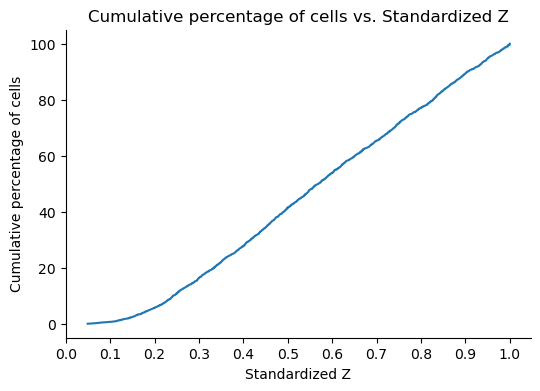

In [3]:
###################################################################################################
################################## Plot1:  Cumulative cell count by standardized Z #################
###################################################################################################

# Sort the standardized_z values
df_sorted = df.sort_values(by='standardized_z')
cumulative_percentage = np.arange(1, len(df_sorted) + 1) / len(df_sorted) * 100
# Find the y-axis value corresponding to standardized_z = 0.3
y_value = cumulative_percentage[df_sorted['standardized_z'] >= 0.3][0]
# Plot cumulative percentage vs. standardized_z
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(df_sorted['standardized_z'], cumulative_percentage, label='Cumulative % of Cells')
ax.set_xticks(np.arange(0, 1.1, 0.1))

ax.spines['bottom'].set_color('black')  
ax.spines['left'].set_color('black')  
ax.spines['top'].set_color('none') 
ax.spines['right'].set_color('none') 

plt.xlabel('Standardized Z')
plt.ylabel('Cumulative percentage of cells')
plt.title('Cumulative percentage of cells vs. Standardized Z')
plt.grid(False)
# plt.legend()

pdf_path = base_dir/'1.cumulative_cell_count_vs._z_30pct.pdf'
plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
plt.show()


In [38]:
cnt_border_cells = df.loc[df['standardized_z'] < 0.3,].shape[0]
cells_border_pct = round(cnt_border_cells * 100/ df.shape[0],2)
print(f'There are around {cells_border_pct}% cells in MTs have located within 30% to the cutting surface, which is {cnt_border_cells} cells')

There are around 16.26% cells in MTs have located within 30% to the cutting surface, which is 401 cells


Use binned method to find the point of morphometric that are close to the neurons in the middle as moving along the standardized Z location

In [5]:
morphometric_list = df.columns[6:-1]
print(len(morphometric_list))
print(morphometric_list)

31
Index(['Bif_ampl_local', 'Bif_ampl_remote', 'Branch_Order', 'Depth',
       'Sum_EucDistance', 'Max_EucDistance', 'Fractal_Dim', 'Height', 'Length',
       'N_bifs', 'N_branch', 'N_stems', 'N_tips', 'Partition_asymmetry',
       'Sum_PathDistance', 'Max_PathDistance', 'Width', 'Terminal_degree',
       'Bif_tilt_local', 'Bif_tilt_remote', 'Bif_torque_local',
       'Bif_torque_remote', 'ABEL_All', 'BAPL_All', 'ABEL_Internal',
       'BAPL_Internal', 'ABEL_Terminal', 'BAPL_Terminal', 'Balancing_Factor',
       'Centripetal_Bias', 'Convexity'],
      dtype='object')


We can have 3 main divisions, angle related, size/length related, and complexity related.
1. Angle related: Bifurcation amplitude local/remote, Bifurcation tilt local/remote, Bifurcation torque local/remote, Centripedal_Bias
2. Size/Length related: Depth, Height, Width, Length, Sum_EucDistance, Max_Eucdistance, Sum_PathDistanc, Max_PathDistance, ABEL_All, BAPL_All, ABEL_Terminal, BAPL_Terminal, ABEL_Internal, BAPL_Internal
3. Complexity relat|ed: N_bifs, N_branch, N_tips, N_stems, Branch_Order, Fractal_Dim, Partition_asymmetry, Terminal_degree, Balancing_Factor, Convexity

In [14]:
# define color coding for 3 main feature groups
features_angle = ['Bif_ampl_local', 'Bif_ampl_remote', 'Bif_tilt_local', 'Bif_tilt_remote', 'Bif_torque_local', 'Bif_torque_remote', 'Centripetal_Bias']
features_length = ['Depth', 'Height', 'Width', 'Length', 'Sum_EucDistance', 'Sum_PathDistance', 'Max_EucDistance', 'Max_PathDistance', 'ABEL_All', 'ABEL_Internal', 'ABEL_Terminal', 'BAPL_All', 'BAPL_Internal', 'BAPL_Terminal']
features_complexity = ['N_bifs', 'N_branch', 'N_tips', 'N_stems', 'Branch_Order', 'Fractal_Dim', 'Partition_asymmetry', 'Terminal_degree', 'Balancing_Factor', 'Convexity']

In [15]:
# bin the standardized Z, each bin is 10% of the distance from the border to the center
bins = np.linspace(0, 1, 11)
df['Z_bin'] = pd.cut(df['standardized_z'], bins=bins, labels=np.round(bins[1:], 2), include_lowest=True)

Plot2: Normalized average by standardized Z for each of the 31 morphometrics

In [39]:
###################################################################################################
################################## Plot2:  Normalized average by standardized Z    #################
###################################################################################################
threshold = 0.8
cutoff_locations = []
pct_to_last_bin = []

loc_10_value = []
loc_20_value = []
loc_30_value = []
loc_40_value = []
with PdfPages(base_dir/'2.morphometric_features_by_binned_locations_2m.pdf') as pdf:
    for var in tqdm(morphometric_list):
        binned_data = df.groupby('Z_bin')[var].mean().reset_index()
        # normalize the mean of each bin, to the last bin (the 10% closest to the center)
        binned_data['var_normalized'] = binned_data[var] / binned_data[var].iloc[-1]
        # find the Z location where the normalized average of the variable reaches 80% of the last bin
        threshold_bin = binned_data[binned_data['var_normalized'] >= threshold].iloc[0]['Z_bin']
        cutoff_locations.append(threshold_bin)
        pct_to_last_bin.append(binned_data.loc[binned_data['Z_bin'] == threshold_bin, 'var_normalized'].values[0])
        loc_10_value.append(binned_data[binned_data['Z_bin'] == 0.1]['var_normalized'].values[0])
        loc_20_value.append(binned_data[binned_data['Z_bin'] == 0.2]['var_normalized'].values[0])
        loc_30_value.append(binned_data[binned_data['Z_bin'] == 0.3]['var_normalized'].values[0])
        loc_40_value.append(binned_data[binned_data['Z_bin'] == 0.4]['var_normalized'].values[0])

        fig, ax = plt.subplots(figsize=(6,6))

        ax.spines['bottom'].set_color('black')  
        ax.spines['left'].set_color('black')  
        ax.spines['top'].set_color('none') 
        ax.spines['right'].set_color('none')
        
        plt.plot(binned_data['Z_bin'], binned_data['var_normalized'], marker = 's')
        # plt.axvline(x=threshold_bin, color='red', linestyle='--', label=f'Feature reaches {threshold*100}%\nof values of the neuron in the middle\nat {threshold_bin*100}% to the border')
        plt.axvline(x=threshold_bin, color='red', linestyle='--')

        plt.yticks(ticks=np.arange(0, 1.2, 0.2), fontsize=15) 
        plt.xticks(ticks=np.arange(0, 1.1, 0.1), fontsize = 14, rotation=45) 
        plt.xlabel('Z_location (binned)', fontsize = 16, fontweight = 'bold')
        plt.ylabel(f'Average Normalized {var}', fontsize = 16, fontweight = 'bold')
        plt.subplots_adjust(left=0.15, right=0.95, top=0.9, bottom=0.2)
        # plt.title(f'Normalized Average {var} for each Z bin')
        # plt.legend(loc = 'lower right')
        
        pdf.savefig()
        plt.close()

100%|██████████| 31/31 [00:01<00:00, 17.67it/s]


In [40]:
# organize the morphometrics and their critical point to a dataframe
df_critical_point = pd.DataFrame({'feature': morphometric_list, 'critical_point': cutoff_locations,
                                   'pct_to_last_bin': pct_to_last_bin, 
                                  'loc_10_value': loc_10_value, 'loc_20_value': loc_20_value, 'loc_30_value': loc_30_value, 'loc_40_value': loc_40_value})    
df_critical_point['Rank'] = df_critical_point['critical_point'].rank(method='dense', ascending=True)
df_critical_point = df_critical_point.sort_values(by=['Rank', 'pct_to_last_bin'], ascending=[True, False])

In [41]:
# sort accordingly
df_critical_point_sorted = df_critical_point.sort_values(by=['Rank', 'loc_10_value', 'loc_20_value', 'loc_30_value', 'loc_40_value'], ascending=[True, False, False, False, False])

In [42]:
# create colors for the 3 main feature groups
df_critical_point_sorted['color'] = df_critical_point_sorted['feature'].apply(
    lambda x: 'darkorange' if x in features_angle else ('lightseagreen' if x in features_length else ('mediumorchid' if x in features_complexity else 'black'))
)

In [ ]:
# define the rank of features based on critical points
rank2_features = ['N_tips', 'N_branch', 'N_bifs', 'ABEL_Terminal', 'BAPL_Terminal']
rank3_features = ['Length', 'Sum_EucDistance', 'Sum_PathDistance']
rank4_features = ['Depth']
rank1_features = [m for m in morphometric_list if m not in rank2_features + rank3_features + rank4_features]

In [43]:
# the sorted features according to critical point
sorted_features = list(df_critical_point_sorted['feature'])

# get the average pct to center cell for Rank 1,2,3,4 features at 10% to surface
values_at_10 = []
for var in tqdm(sorted_features):
    binned_data = df.groupby('Z_bin')[var].mean().reset_index()
    binned_data['var_normalized'] = binned_data[var] / binned_data[var].iloc[-1]
    value_at_10 = binned_data.loc[binned_data['Z_bin'] == 0.1, 'var_normalized'].values[0]
    values_at_10.append(value_at_10)
value_at_10_df = pd.DataFrame({'feature': sorted_features, 'pct_to_last_bin': values_at_10})

# get the average pct to center cell for Rank 2,3,4 features at 20% to surface
values_at_20 = []
for var in tqdm(sorted_features):
    if var in rank2_features + rank3_features + rank4_features:
        binned_data = df.groupby('Z_bin')[var].mean().reset_index()
        binned_data['var_normalized'] = binned_data[var] / binned_data[var].iloc[-1]
        value_at_20 = binned_data.loc[binned_data['Z_bin'] == 0.2, 'var_normalized'].values[0]
    else:
        value_at_20 = 0
    values_at_20.append(value_at_20)
value_at_20_df = pd.DataFrame({'feature': sorted_features, 'pct_to_last_bin': values_at_20})

# get the average pct to center cell for Rank 3,4 features at 30% to surface
values_at_30 = []
for var in tqdm(sorted_features):
    if var in rank3_features + rank4_features:
        binned_data = df.groupby('Z_bin')[var].mean().reset_index()
        binned_data['var_normalized'] = binned_data[var] / binned_data[var].iloc[-1]
        value_at_30 = binned_data.loc[binned_data['Z_bin'] == 0.3, 'var_normalized'].values[0]
    else:
        value_at_30 = 0
    values_at_30.append(value_at_30)
value_at_30_df = pd.DataFrame({'feature': sorted_features, 'pct_to_last_bin': values_at_30})

# get the average pct to center cell for Rank 4 features at 40% to surface
values_at_40 = []
for var in tqdm(sorted_features):
    if var in rank4_features:
        binned_data = df.groupby('Z_bin')[var].mean().reset_index()
        binned_data['var_normalized'] = binned_data[var] / binned_data[var].iloc[-1]
        value_at_40 = binned_data.loc[binned_data['Z_bin'] == 0.4, 'var_normalized'].values[0]
    else: 
        value_at_40 = 0
    values_at_40.append(value_at_40)
value_at_40_df = pd.DataFrame({'feature': sorted_features, 'pct_to_last_bin': values_at_40})

  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:00<00:00, 15490.04it/s]


Plot3:  Normalized average by critical points for each feature

C:\Users\yanyanming77\AppData\Local\Temp\ipykernel_46048\4276746670.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(df_critical_point_sorted['feature'], rotation=45, ha='right', size = 13)


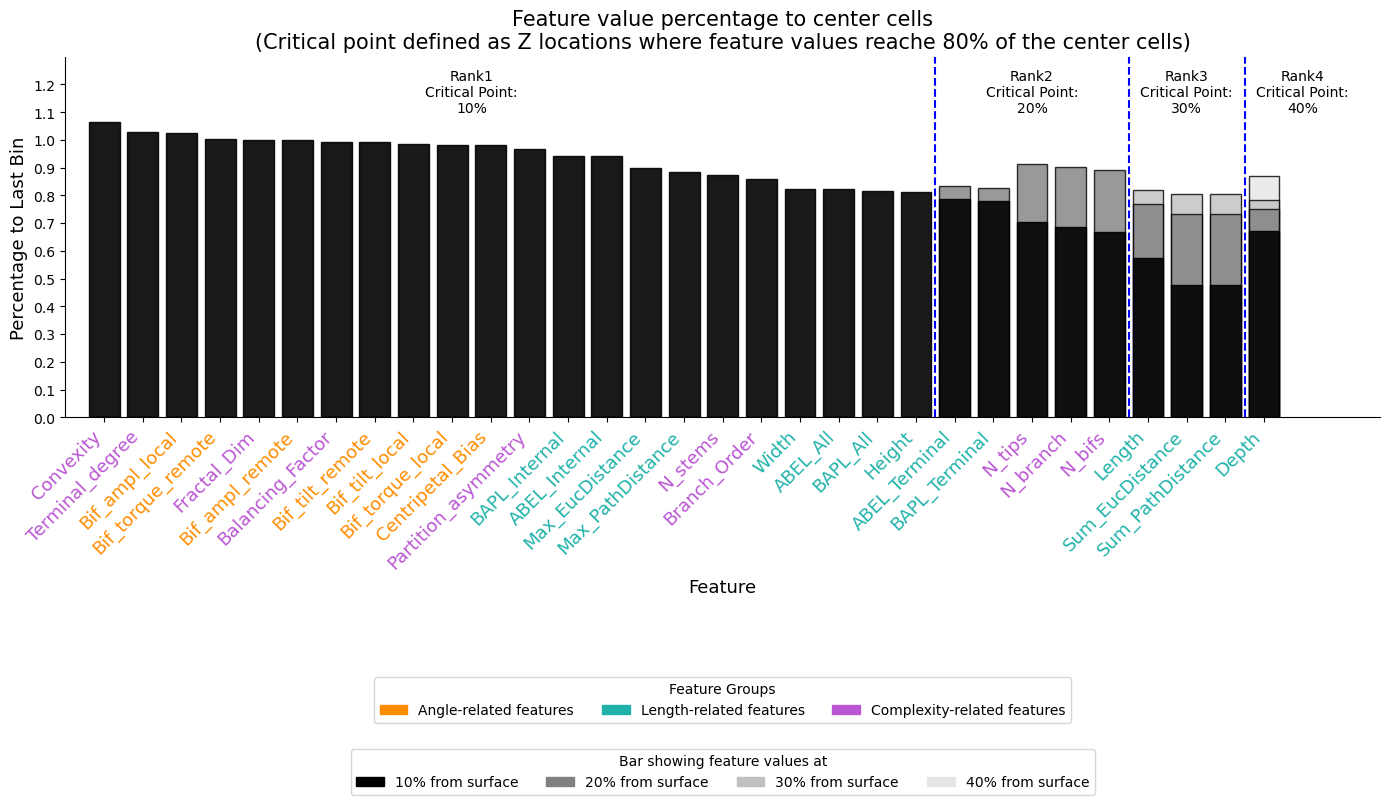

In [44]:
###################################################################################################
###### Plot3: Bar plot - Normalized average at 10%, 20%, 30%, 40% level for each feature   #################
###################################################################################################

fig, ax = plt.subplots(figsize=(14,16))

ax.spines['bottom'].set_color('black')  
ax.spines['left'].set_color('black')  
ax.spines['top'].set_color('none') 
ax.spines['right'].set_color('none')

plt.bar(value_at_40_df['feature'], value_at_40_df['pct_to_last_bin'], color='#E6E6E6', alpha=0.8, edgecolor='black')
plt.bar(value_at_30_df['feature'], value_at_30_df['pct_to_last_bin'], color='#C0C0C0', alpha=0.8, edgecolor='black')
plt.bar(value_at_20_df['feature'], value_at_20_df['pct_to_last_bin'], color='#808080', alpha=0.8, edgecolor='black')
plt.bar(value_at_10_df['feature'], value_at_10_df['pct_to_last_bin'], color='#000000', alpha=0.9, edgecolor='black')

plt.ylim(0, 1.3)
plt.xlim(-1, 33)
plt.yticks(np.arange(0, 1.3, 0.1))
plt.xlabel('Feature', size = 13)
plt.ylabel('Percentage to Last Bin', size = 13)
plt.title(f'Feature value percentage to center cells\n(Critical point defined as Z locations where feature values reache 80% of the center cells)', size = 15)
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add vertical dashed line
plt.axvline(x=21.5, color='blue', linestyle='--')
plt.axvline(x=26.5, color='blue', linestyle='--')
plt.axvline(x=29.5, color='blue', linestyle='--')

# Add annotation
plt.annotate(f'Rank1\nCritical Point:\n10%', xy=(9.5, 1.1), xytext=(9.5, 1.1), ha='center', fontsize=10, color='black')
plt.annotate(f'Rank2\nCritical Point:\n20%', xy=(24, 1.1), xytext=(24, 1.1), ha='center', fontsize=10, color='black')
plt.annotate(f'Rank3\nCritical Point:\n30%', xy=(28, 1.1), xytext=(28, 1.1), ha='center', fontsize=10, color='black')
plt.annotate(f'Rank4\nCritical Point:\n40%', xy=(31, 1.1), xytext=(31, 1.1), ha='center', fontsize=10, color='black')

# Set x-axis labels with different colors
ax = plt.gca()
ax.set_xticklabels(df_critical_point_sorted['feature'], rotation=45, ha='right', size = 13)
for tick_label, color in zip(ax.get_xticklabels(), list(df_critical_point_sorted['color'])):
    tick_label.set_color(color)

# First custom legend
legend_handles1 = [
    mpatches.Patch(color='darkorange', label='Angle-related features'),
    mpatches.Patch(color='lightseagreen', label='Length-related features'),
    mpatches.Patch(color='mediumorchid', label='Complexity-related features')
]
legend1 = ax.legend(handles=legend_handles1, title='Feature Groups', loc='upper center', 
                    bbox_to_anchor=(0.5, -0.7), ncol=3)

# Second custom legend
legend_handles2 = [
    mpatches.Patch(color='#000000', label=rf'10% from surface'),
    mpatches.Patch(color='#808080', label=rf'20% from surface'),
    mpatches.Patch(color='#C0C0C0', label=rf'30% from surface'),
    mpatches.Patch(color='#E6E6E6', label=rf'40% from surface')
]
legend2 = ax.legend(handles=legend_handles2, title='Bar showing feature values at', loc='upper center', 
                    bbox_to_anchor=(0.5, -0.9), ncol=4)

# Manually add the first legend back to the plot
ax.add_artist(legend1)

plt.tight_layout()

pdf_path = base_dir/'3.pct_to_last_bin_31features_by_rank_stacked.pdf'
plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)
plt.show()

Look at the surface neuron distribution in different groups (cell type, striatal.subregion, DMs)

In [45]:
# create the dataset that are only CP neurons
df_CP = df.loc[df['Striatal.Subregion'].isin(['CPr', 'CPi', 'CPc']),:]
print(df_CP.shape) # 224

(2248, 39)


In [47]:
## define a function to generate the stacked bar plot for the proportion of surface neurons in each category
def stacked_bar_border_cells(df, cat_var, cat_name, number, fig_size = (6,5), save = False):

    df['border'] = df['standardized_z'].apply(lambda x: 'Yes' if x < 0.3 else 'No')
    border_counts = df.groupby(cat_var)['border'].value_counts(normalize=True).unstack().reindex(columns=['Yes', 'No'])
    group_sizes = df[cat_var].value_counts().sort_index()

    contingency_table = pd.crosstab(df[cat_var], df['border'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    ax = border_counts.plot(kind='bar', stacked=True, figsize=fig_size, width=0.8)
    ax.set_xticklabels([f'{grp} (n={group_sizes[grp]})' for grp in group_sizes.index])

    # Add percentage annotation
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if height > 0:  
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f'{height:.1%}',
                    ha='center', va='center', fontsize=10, color='black'
                )
    plt.xlabel(f'{cat_name}')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.gcf().suptitle(f'Border cells defined as located within 30% to the cutting surface of each tissue section', fontsize=10)
    plt.title(f'Proportion of border cells in each {cat_var}\nChi-square test P-value: {p:.2f}')
    plt.legend(title='Border cells', bbox_to_anchor=(1.23, 0.5), loc='right', ncol=1)

    if save:
        pdf_path = base_dir/rf"{number}.barplot_proportion_of_surface_neurons_in_{cat_name}.pdf"
        plt.savefig(pdf_path, format="pdf", bbox_inches="tight", dpi=300)

    plt.show()

C:\Users\yanyanming77\AppData\Local\Temp\ipykernel_46048\1148525481.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['border'] = df['standardized_z'].apply(lambda x: 'Yes' if x < 0.3 else 'No')


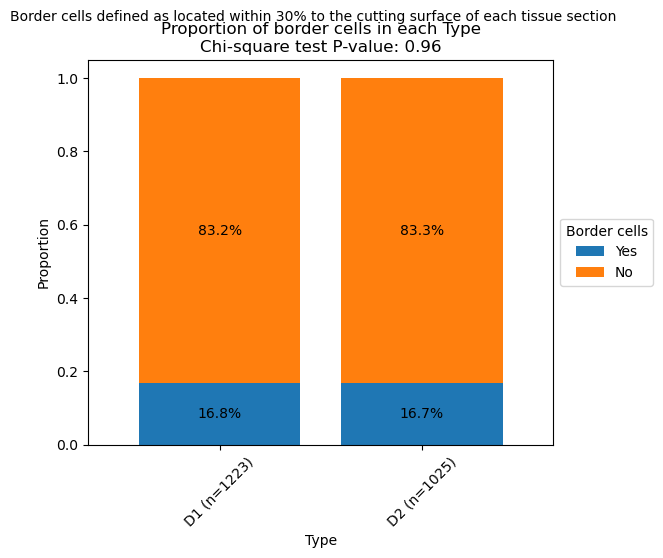

In [48]:
# surface neuron distribution in in D1/D2
stacked_bar_border_cells(df_CP, 'Type', 'Type', number=4, fig_size=(6,5), save = True)

C:\Users\yanyanming77\AppData\Local\Temp\ipykernel_46048\526920712.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CP['Striatal.Subregion'] = df_CP['Striatal.Subregion'].astype('category')
C:\Users\yanyanming77\AppData\Local\Temp\ipykernel_46048\526920712.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_CP['Striatal.Subregion'] = df_CP['Striatal.Subregion'].cat.reorder_categories(['CPr', 'CPi', 'CPc'], ordered=True)
C:\Users\yanyanming77\AppData\Local\Temp\ipykernel_46048\1148525481.py:4: Setti

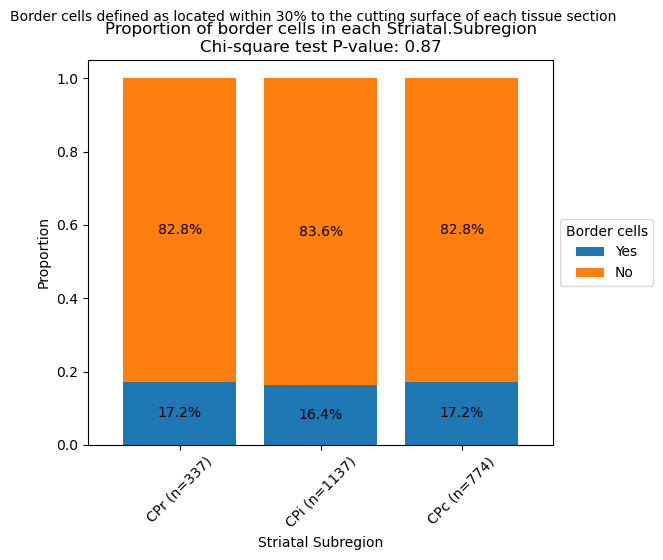

In [49]:
# convert the striatal.subregion to categorical variable with order of CPr, CPi and CPc
df_CP['Striatal.Subregion'] = df_CP['Striatal.Subregion'].astype('category')
df_CP['Striatal.Subregion'] = df_CP['Striatal.Subregion'].cat.reorder_categories(['CPr', 'CPi', 'CPc'], ordered=True)

# in CPr/i/c
stacked_bar_border_cells(df_CP, 'Striatal.Subregion', 'Striatal Subregion', number=5, fig_size=(6,5), save = True)

In [50]:
# first get all cells that are in MTs
cell_DM_assginment= pd.read_csv(base_dir/'morpho_un_adjusted_box_cluster_xyz_D1D2.csv')[['file_path', 'Box', 'Cluster']]
cells_DM = pd.merge(cell_DM_assginment, df[['file_path', 'standardized_z']], on = 'file_path')
print(cells_DM.shape) 

(2466, 4)


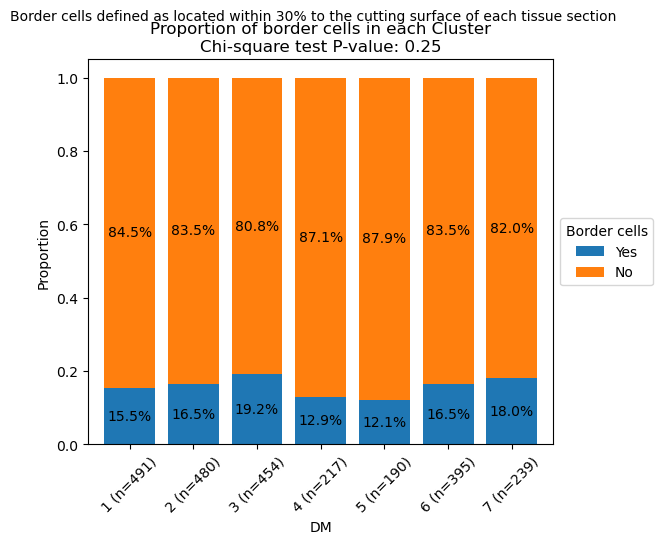

In [52]:
stacked_bar_border_cells(cells_DM, 'Cluster', 'DM', number=6, fig_size = (6,5), save = True)